In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO2_247.JPG
/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO4_242.JPG
/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO2_124.JPG
/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO3_037.jpg
/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO1_153.JPG
/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO1_147.JPG
/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO4_147.JPG
/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images/Tungro/TUNGRO2_148.JPG
/kaggle/input/da

## required libraries

In [2]:
!pip install -q torchinfo thop codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 8.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 86.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.2 MB/s eta 0:00:00:00:01


## importing libraries

In [3]:
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

from torchinfo import summary
from thop import profile
from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")

## device config

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


## random seed 

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

## dataset

In [5]:
dataset_path = "/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images"

print(dataset_path)

/kaggle/input/datasets/maimunulkjisan/rice-leaf-dataset-from-mendeley-data/Rice Leaf Disease Images


## preprocessing & augmentation

In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## loading the dataset

In [25]:
ull_dataset = datasets.ImageFolder(root=dataset_path)

class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Total images: {len(full_dataset)}")

Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']
Number of classes: 4
Total images: 5932


## creating splits

In [26]:
from torch.utils.data import Subset

indices = list(range(len(full_dataset)))

random.shuffle(indices)

train_split = int(0.7 * len(indices))
val_split = int(0.85 * len(indices))

train_indices = indices[:train_split]
val_indices = indices[train_split:val_split]
test_indices = indices[val_split:]

print(f"Train size: {len(train_indices)}")
print(f"Validation size: {len(val_indices)}")
print(f"Test size: {len(test_indices)}")

Train size: 4152
Validation size: 890
Test size: 890


## transform-specific sets

In [27]:
train_dataset_full = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transforms
)

test_dataset_full = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transforms
)

train_dataset = Subset(train_dataset_full, train_indices)

val_dataset = Subset(test_dataset_full, val_indices)

test_dataset = Subset(test_dataset_full, test_indices)

## data loaders

In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## sample images before training

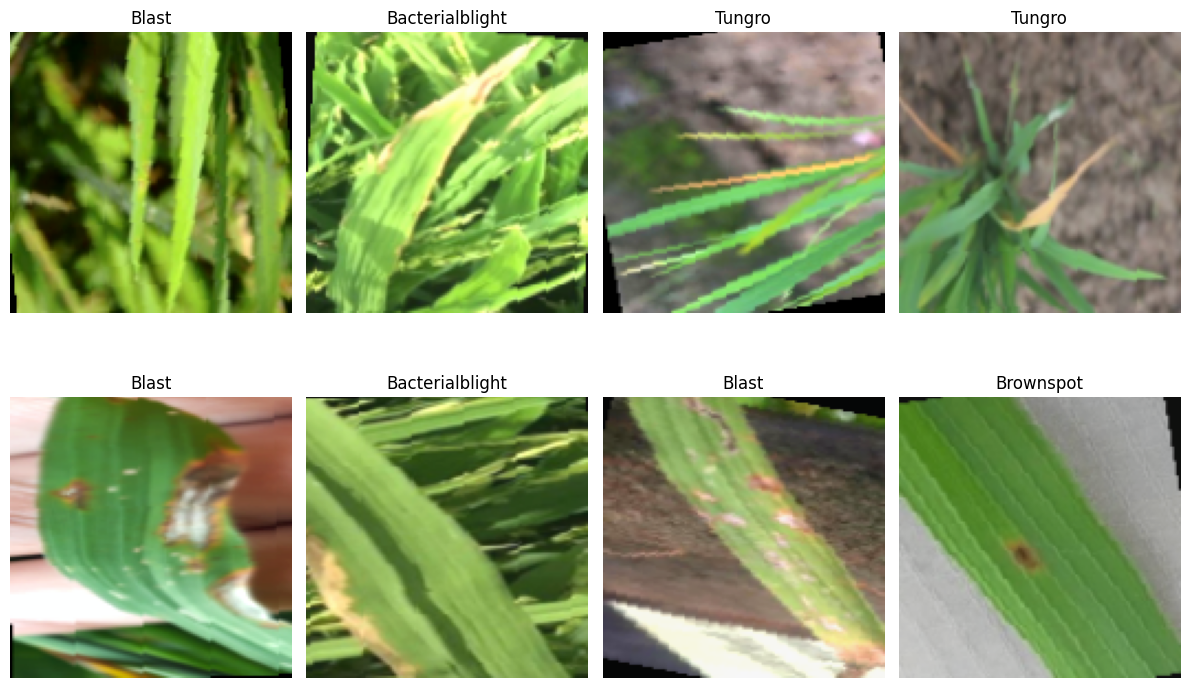

In [29]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title(class_names[labels[i]])

plt.tight_layout()
plt.show()

## the custom CNN

In [30]:
class RiceLeafCNN(nn.Module):
    
    def __init__(self, num_classes):
        super(RiceLeafCNN, self).__init__()
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            
            nn.Flatten(),
            
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## model initialization

In [31]:
model = RiceLeafCNN(num_classes=num_classes).to(device)

print(model)

RiceLeafCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

## model summary

In [32]:
summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
RiceLeafCNN                              [1, 4]                    --
├─Sequential: 1-1                        [1, 256, 8, 8]            --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 128]         64
│    └─ReLU: 2-3                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-4                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-5                       [1, 64, 64, 64]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 64, 64]           128
│    └─ReLU: 2-7                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-8                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-9                       [1, 128, 32, 32]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 32, 32]          256
│    └─ReLU: 2-11                        [1, 128, 32, 32]          --
│   

## loss function & optimizer

In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)


## training config

In [34]:
EPOCHS = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0

## training loop

In [35]:
tracker = EmissionsTracker()
tracker.start()

start_time = time.time()

for epoch in range(EPOCHS):
    
    # ================= TRAINING =================
    
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # ================= VALIDATION =================
    
    model.eval()
    
    val_running_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        
        for images, labels in val_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * correct / total
    
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    scheduler.step(val_loss)
    
    # Save Best Model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        torch.save(
            model.state_dict(),
            "best_rice_leaf_cnn.pth"
        )
    
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

training_time = time.time() - start_time

emissions = tracker.stop()

print("\nTraining Complete.")

[codecarbon WARNING @ 23:59:06] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 23:59:06] [setup] RAM Tracking...
[codecarbon INFO @ 23:59:06] [setup] CPU Tracking...
[codecarbon WARNING @ 23:59:06] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 23:59:06] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 23:59:06] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 23:59:06] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 23:59:06] [setup] GPU Tracking...
[codecarbon INFO @ 23:59:07] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 23:59:07] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Epoch [1/30] | Train Loss: 1.0271 | Train Acc: 64.72% | Val Loss: 0.6199 | Val Acc: 72.81%


[codecarbon INFO @ 23:59:40] Energy consumed for RAM : 0.000167 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 23:59:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 23:59:40] Energy consumed for All CPU : 0.000354 kWh
[codecarbon INFO @ 23:59:40] Energy consumed for all GPUs : 0.000378 kWh. Total GPU Power : 45.10889327709749 W
[codecarbon INFO @ 23:59:40] 0.000899 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:59:55] Energy consumed for RAM : 0.000250 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 23:59:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 23:59:55] Energy consumed for All CPU : 0.000531 kWh
[codecarbon INFO @ 23:59:55] Energy consumed for all GPUs : 0.000568 kWh. Total GPU Power : 45.76234481644135 W
[codecarbon INFO @ 23:59:55] 0.001349 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch [2/30] | Train Loss: 0.6304 | Train Acc: 76.35% | Val Loss: 0.4042 | Val Acc: 84.16%


[codecarbon INFO @ 00:00:10] Energy consumed for RAM : 0.000333 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:00:10] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 00:00:10] Energy consumed for All CPU : 0.000708 kWh
[codecarbon INFO @ 00:00:10] Energy consumed for all GPUs : 0.000758 kWh. Total GPU Power : 45.5441648138799 W
[codecarbon INFO @ 00:00:10] 0.001799 kWh of electricity and 0.000000 L of water were used since the beginning.


...

Epoch [28/30] | Train Loss: 0.0291 | Train Acc: 98.89% | Val Loss: 0.0034 | Val Acc: 100.00%


[codecarbon INFO @ 00:10:25] Energy consumed for RAM : 0.003747 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:10:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 00:10:25] Energy consumed for All CPU : 0.007963 kWh
[codecarbon INFO @ 00:10:25] Energy consumed for all GPUs : 0.008624 kWh. Total GPU Power : 45.85017676053662 W
[codecarbon INFO @ 00:10:25] 0.020334 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 00:10:40] Energy consumed for RAM : 0.003830 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:10:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 00:10:40] Energy consumed for All CPU : 0.008140 kWh
[codecarbon INFO @ 00:10:40] Energy consumed for all GPUs : 0.008817 kWh. Total GPU Power : 46.35654360995199 W
[codecarbon INFO @ 00:10:40] 0.020787 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch [29/30] | Train Loss: 0.0288 | Train Acc: 99.25% | Val Loss: 0.0053 | Val Acc: 100.00%


[codecarbon INFO @ 00:10:55] Energy consumed for RAM : 0.003913 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:10:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 00:10:55] Energy consumed for All CPU : 0.008317 kWh
[codecarbon INFO @ 00:10:55] Energy consumed for all GPUs : 0.009008 kWh. Total GPU Power : 45.88386921507756 W
[codecarbon INFO @ 00:10:55] 0.021238 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 00:11:07] Energy consumed for RAM : 0.003981 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 00:11:07] Delta energy consumed for CPU with constant : 0.000144 kWh, power : 42.5 W
[codecarbon INFO @ 00:11:07] Energy consumed for All CPU : 0.008460 kWh
[codecarbon INFO @ 00:11:07] Energy consumed for all GPUs : 0.009164 kWh. Total GPU Power : 46.0639124972864 W
[codecarbon INFO @ 00:11:07] 0.021605 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 00:11:

Epoch [30/30] | Train Loss: 0.0221 | Train Acc: 99.18% | Val Loss: 0.0041 | Val Acc: 100.00%

Training Complete.


## learning curves

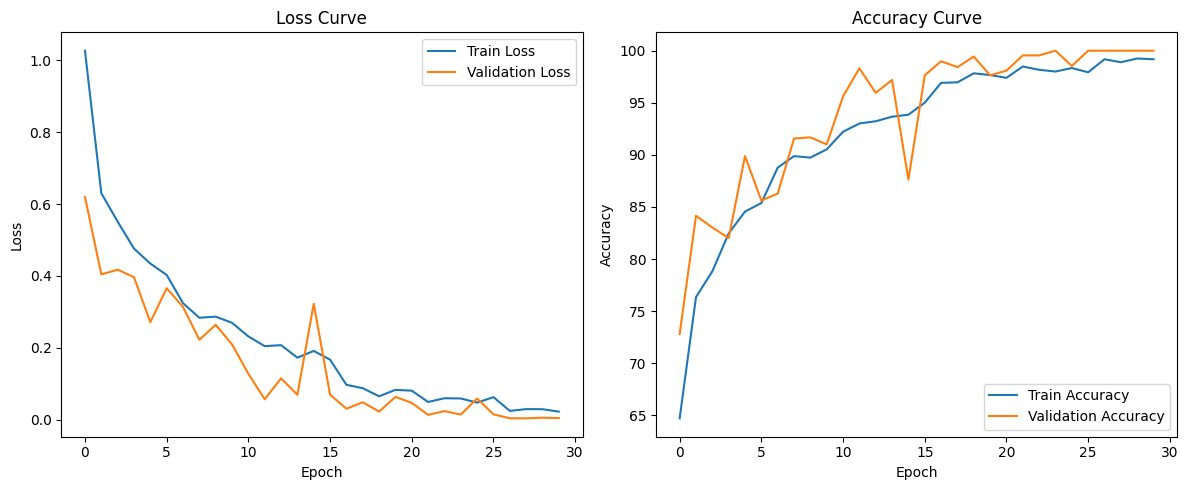

In [36]:
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.tight_layout()
plt.show()

## load best model

In [37]:
model.load_state_dict(torch.load("best_rice_leaf_cnn.pth"))

model.eval()

RiceLeafCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

## evaluating the model

In [39]:
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)
        
        _, predicted = torch.max(outputs, 1)
        
        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

## evaluation metrics

In [40]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

kappa = cohen_kappa_score(
    all_labels,
    all_preds
)

# ROC-AUC
labels_binarized = label_binarize(
    all_labels,
    classes=range(num_classes)
)

roc_auc = roc_auc_score(
    labels_binarized,
    all_probs,
    multi_class='ovr'
)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"Cohen Kappa  : {kappa:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

Accuracy     : 0.9978
Precision    : 0.9978
Recall       : 0.9978
F1 Score     : 0.9978
Cohen Kappa  : 0.9970
ROC-AUC      : 1.0000


## classification report

In [41]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print(report)

                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       239
          Blast       1.00      0.99      1.00       194
      Brownspot       1.00      1.00      1.00       234
         Tungro       1.00      1.00      1.00       223

       accuracy                           1.00       890
      macro avg       1.00      1.00      1.00       890
   weighted avg       1.00      1.00      1.00       890



## confusion matrix

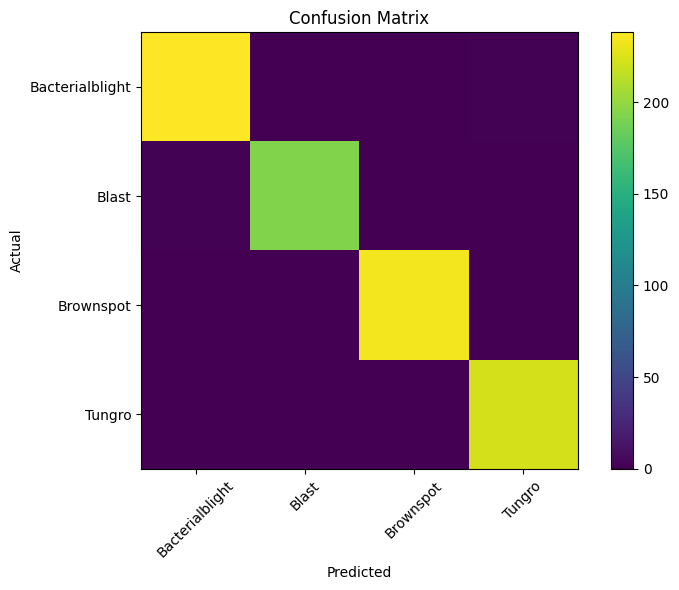

In [42]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation='nearest')

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## FLOPs & parameters calculations

In [43]:
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

flops, params = profile(
    model,
    inputs=(dummy_input,),
    verbose=False
)

print(f"FLOPs      : {flops / 1e9:.3f} GFLOPs")
print(f"Parameters : {params / 1e6:.3f} Million")

FLOPs      : 0.253 GFLOPs
Parameters : 8.911 Million


## energy and carbon emissions

In [44]:
print(f"Training Time       : {training_time:.2f} seconds")
print(f"Carbon Emissions    : {emissions:.6f} kgCO2eq")

Training Time       : 717.21 seconds
Carbon Emissions    : 0.009779 kgCO2eq
